In [8]:
from collections import defaultdict
from pathlib import Path

import cartopy.crs as ccrs
import iris
import iris.plot as iplt
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

In [9]:
# This is the main location for the simulation output.
dy3dir = Path('/gws/nopw/j04/kscale/DYAMOND3_reruns')
# We ran out of space, so some output is located under scratch.
dy3dir_scratch = Path('/work/scratch-pw5/rwjones/kscale/DYAMOND3_reruns')

In [10]:
def find_sims(dirs):
    """Returns a dict of sims, where values are another dict containing basedir, is_global and on_scratch"""
    sims = {}
    for d in dirs:
        for first_ppa in sorted(d.glob('*/*/field.pp/apvera.pp/*.apvera_20200120T0000Z.pp')):
            simkey = '.'.join(first_ppa.name.split('.')[:-2])
            basedir = first_ppa.parent.parent.parent
            is_global = 'glm' in simkey
            on_scratch = 'gws' not in str(first_ppa)
            sims[simkey] = {'basedir': basedir, 'is_global': is_global, 'on_scratch': on_scratch}
    return sims


sims = find_sims([dy3dir, dy3dir_scratch])

In [11]:
for simkey in sorted(sims):
    siminfo = sims[simkey]
    print(f'{simkey}:')
    for k, v in siminfo.items():
        print(f'  {k:<11} = {v}')

Africa_km4p4_CoMA9_TBv1.n2560_CoMA9_hier_v2:
  basedir     = /work/scratch-pw5/rwjones/kscale/DYAMOND3_reruns/5km-CoMA9/Africa_km4p4_CoMA9_TBv1
  is_global   = False
  on_scratch  = True
Africa_km4p4_RAL3P3.n2560_CoMA9_hier_v2:
  basedir     = /gws/nopw/j04/kscale/DYAMOND3_reruns/5km-CoMA9/Africa_km4p4_RAL3P3
  is_global   = False
  on_scratch  = False
CTC_km4p4_CoMA9_TBv1.n2560_CoMA9_hier_v2:
  basedir     = /work/scratch-pw5/rwjones/kscale/DYAMOND3_reruns/5km-CoMA9/CTC_km4p4_CoMA9_TBv1
  is_global   = False
  on_scratch  = True
SAmer_km4p4_CoMA9_TBv1.n2560_CoMA9_hier_v2:
  basedir     = /work/scratch-pw5/rwjones/kscale/DYAMOND3_reruns/5km-CoMA9/SAmer_km4p4_CoMA9_TBv1
  is_global   = False
  on_scratch  = True
SAmer_km4p4_RAL3P3.n2560_CoMA9_hier_v2:
  basedir     = /work/scratch-pw5/rwjones/kscale/DYAMOND3_reruns/5km-CoMA9/SAmer_km4p4_RAL3P3
  is_global   = False
  on_scratch  = True
SEA_km4p4_CoMA9_TBv1.n2560_CoMA9_hier_v2:
  basedir     = /work/scratch-pw5/rwjones/kscale/DYAMOND3_re

In [12]:
def _parse_date_from_pp_path(path):
    datestr = path.stem.split('.')[-1].split('_')[1]
    if datestr[-1] == 'Z':
        return pd.to_datetime(datestr, format="%Y%m%dT%H%MZ")
    else:
        return pd.to_datetime(datestr, format="%Y%m%dT%H")


def find_dyamond3_pp_dates_to_paths(basedir):
    """Search for pp_paths with a specific date (N.B. filename sensitive)."""
    pp_paths = sorted(basedir.glob('field.pp/apve*/**/*.pp'))
    pp_paths = [p for p in pp_paths if p.is_file()]
    dates_to_paths = defaultdict(dict)
    for path in pp_paths:
        if 'apvere' in path.stem:
            continue
        stream = path.name.split('.')[-2][5]
        dates_to_paths[_parse_date_from_pp_path(path)][stream] = path
    # Only keep completed downloads.
    dates_to_paths = {k: v for k, v in dates_to_paths.items() if len(v) == 4}
    return dates_to_paths

In [6]:
# siminfo = sims['glm.n2560_RAL3p3_tuned']

# dates_to_paths = find_dyamond3_pp_dates_to_paths(siminfo['basedir'])

In [16]:
# start = pd.Timestamp("2020-01-20")
# end = pd.Timestamp("2020-01-23")

# x_cubes = []
# y_cubes = []

# for dt, paths in sorted(dates_to_paths.items()):
#     if start <= dt < end:

#         # choose stream, e.g. 'a'
#         path = paths['c']

#         # load your variable
#         cube = iris.load_cube(str(path), 'x_wind')
#         cube_crop = cube.extract(iris.Constraint(pressure=850))
#         cube_reg = cube_crop.intersection(
#             latitude=(-35, -5),
#             longitude=(5, 50),
#         )

#         cube_y = iris.load_cube(str(path), 'y_wind')
#         cube_crop_y = cube_y.extract(iris.Constraint(pressure=850))
#         cube_reg_y = cube_crop_y.intersection(
#             latitude=(-35, -5),
#             longitude=(5, 50),
#         )


#         x_cubes.append(cube_reg)
#         y_cubes.append(cube_reg_y)

# # combine all times together
# x_combined = iris.cube.CubeList(x_cubes).concatenate_cube()
# y_combined = iris.cube.CubeList(y_cubes).concatenate_cube()

In [ ]:
# x_da = xr.DataArray.from_iris(x_combined)
# y_da = xr.DataArray.from_iris(y_combined)

In [2]:
# import os

# folder = '//work/scratch-pw5/hjwood/p_budget_terms'
# fname = "x_MAM_mean_saf.nc"
# file = os.path.join(folder, fname)
# ds = xr.open_dataset(file)
# print(ds)

<xarray.Dataset> Size: 29MB
Dimensions:                  (pressure: 18, latitude: 640, longitude: 640)
Coordinates:
  * pressure                 (pressure) float32 72B 100.0 150.0 ... 975.0 1e+03
  * latitude                 (latitude) float32 3kB -34.97 -34.92 ... -5.016
  * longitude                (longitude) float32 3kB 5.062 5.133 ... 49.92 49.99
    forecast_period          timedelta64[ns] 8B ...
    forecast_reference_time  datetime64[ns] 8B ...
    time                     datetime64[ns] 8B ...
Data variables:
    x_wind                   (pressure, latitude, longitude) float32 29MB ...


In [17]:
# plotting = ds.sel(pressure=850)
# pr = plotting['x_wind']
# print(pr.values)

In [18]:
# fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()})
# ax.set_global()
# plot = pr.plot(
#     ax=ax,
#     x="longitude",
#     y="latitude",
#     transform=ccrs.PlateCarree(),
#     cmap="RdBu",
#     cbar_kwargs={"label": "x-wind [m/s]", "aspect": 10}
# )
# gl = ax.gridlines(draw_labels=True)
# gl.top_labels = False
# gl.right_labels = False
# ax.set_extent([5,50,-35,-5])
# ax.coastlines(color="black")
# plt.show()

In [13]:
# mean over time dimension
# mean_cube = combined.collapsed('time', iris.analysis.MEAN)

# print(mean_cube)

In [13]:
siminfo = sims['glm.n2560_RAL3p3_tuned']

dates_to_paths = find_dyamond3_pp_dates_to_paths(siminfo['basedir'])
# dates_to_paths is a mapping, keyed by a pd.Timestamp, that gives all .pp files for a given date.
dates_to_paths[pd.Timestamp('2020-01-20 00:00')]

{'a': PosixPath('/gws/nopw/j04/kscale/DYAMOND3_reruns/5km-RAL3p3-tuned/glm/field.pp/apvera.pp/glm.n2560_RAL3p3_tuned.apvera_20200120T0000Z.pp'),
 'b': PosixPath('/gws/nopw/j04/kscale/DYAMOND3_reruns/5km-RAL3p3-tuned/glm/field.pp/apverb.pp/glm.n2560_RAL3p3_tuned.apverb_20200120T0000Z.pp'),
 'c': PosixPath('/gws/nopw/j04/kscale/DYAMOND3_reruns/5km-RAL3p3-tuned/glm/field.pp/apverc.pp/glm.n2560_RAL3p3_tuned.apverc_20200120T0000Z.pp'),
 'd': PosixPath('/gws/nopw/j04/kscale/DYAMOND3_reruns/5km-RAL3p3-tuned/glm/field.pp/apverd.pp/glm.n2560_RAL3p3_tuned.apverd_20200120T0000Z.pp')}

In [19]:
# We can now construct an iris cube list, loading all streams or just a single stream.
# You can apply a constraint to just load a single cube here
# Load all cubes for time:
# cubes = iris.load(dates_to_paths[pd.Timestamp('2020-01-20 00:00')].values())
# Load single stream:
cubes = iris.load(dates_to_paths[pd.Timestamp('2020-01-20 00:00')]['c'])

In [20]:
cubes

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/iris/common/mixin.py:203: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


[<iris 'Cube' of Heavyside function on pressure levels / (1) (time: 5; pressure: 25; latitude: 3841; longitude: 5120)>,
<iris 'Cube' of mass_fraction_of_cloud_ice_crystals_in_air / (kg kg-1) (time: 5; model_level_number: 60; latitude: 3840; longitude: 5120)>,
<iris 'Cube' of air_pressure / (Pa) (time: 4; model_level_number: 60; latitude: 3840; longitude: 5120)>,
<iris 'Cube' of mass_fraction_of_cloud_ice_in_air / (kg kg-1) (time: 5; model_level_number: 60; latitude: 3840; longitude: 5120)>,
<iris 'Cube' of mass_fraction_of_cloud_liquid_water_in_air / (kg kg-1) (time: 5; model_level_number: 60; latitude: 3840; longitude: 5120)>,
<iris 'Cube' of mass_fraction_of_graupel_in_air / (kg kg-1) (time: 5; model_level_number: 60; latitude: 3840; longitude: 5120)>,
<iris 'Cube' of mass_fraction_of_rain_in_air / (kg kg-1) (time: 5; model_level_number: 60; latitude: 3840; longitude: 5120)>,
<iris 'Cube' of relative_humidity / (%) (time: 5; pressure: 25; latitude: 3841; longitude: 5120)>,
<iris 'Cube' of specific_humidity / (1) (time: 5; pressure: 25; latitude: 3841; longitude: 5120)>,
<iris 'Cube' of upward_air_velocity / (m s-1) (time: 5; pressure: 25; latitude: 3840; longitude: 5120)>,
<iris 'Cube' of x_wind / (m s-1) (time: 5; pressure: 25; latitude: 3841; longitude: 5120)>,
<iris 'Cube' of y_wind / (m s-1) (time: 5; pressure: 25; latitude: 3841; longitude: 5120)>]

In [17]:
# x = cubes.extract_cube('x_wind')
# y = cubes.extract_cube('y_wind')

In [18]:
# x
# y

In [20]:
# # We can convert into xarray if we prefer:
# x_da = xr.DataArray.from_iris(x)
# y_da = xr.DataArray.from_iris(x)

In [14]:
# x_da
# y_da

In [10]:
x_m = x_da.mean("time")
y_m = y_da.mean("time")

In [11]:
x_eddy = (x_da - x_m)
y_eddy = (y_da - y_m)

In [12]:
x_eddy_m = x_eddy.mean("time")
y_eddy_m = y_eddy.mean("time")

In [13]:
print(y_eddy_m)

<xarray.DataArray 'y_wind' (latitude: 640, longitude: 640)> Size: 2MB
dask.array<mean_agg-aggregate, shape=(640, 640), dtype=float32, chunksize=(640, 640), chunktype=numpy.ndarray>
Coordinates:
  * latitude                 (latitude) float64 5kB -34.97 -34.92 ... -5.016
  * longitude                (longitude) float64 5kB 5.062 5.133 ... 49.92 49.99
    forecast_reference_time  datetime64[ns] 8B 2020-01-20
    pressure                 float64 8B 850.0


In [40]:
# x_plot = x_m.sel(pressure=850)
# y_plot = y_m.sel(pressure=850)

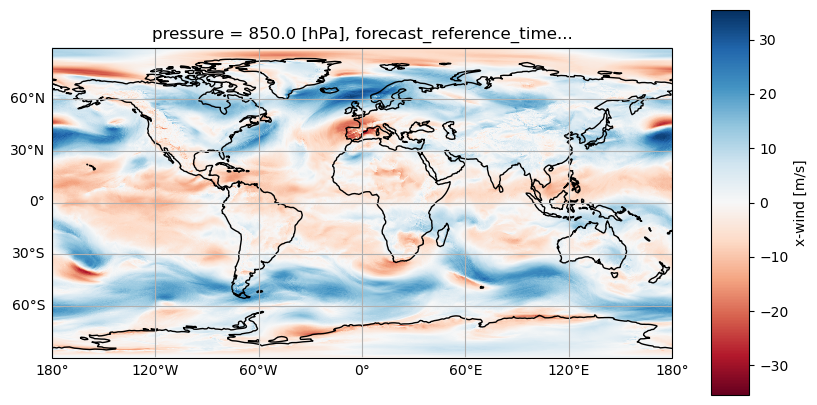

In [48]:
# fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()})
# ax.set_global()
# plot = x_plot.plot(
#     ax=ax,
#     x="longitude",
#     y="latitude",
#     transform=ccrs.PlateCarree(),
#     cmap="RdBu",
#     cbar_kwargs={"label": "x-wind [m/s]", "aspect": 10}
# )
# gl = ax.gridlines(draw_labels=True)
# gl.top_labels = False
# gl.right_labels = False
# ax.coastlines(color="black")
# plt.show()